# Credit Scoring — Fase 5: Scorecard Interpretable (WoE/IV)

Esta fase implementa el **estándar de la industria bancaria**: una scorecard que convierte el modelo en un sistema de puntos auditable y regulable.  

**Fórmula de escala:**
```
Score = A - B × ln(odds)
Puntos_variable_bin = -(WoE × β_i × B)
```
donde `A = 600` (score base), `B = PDO / ln(2)` con `PDO = 20` (cada 20 puntos doblan los odds).

**Bandas de riesgo:**
- Score < 550 → Alto riesgo → Rechazar
- 550–650 → Riesgo medio → Revisión manual
- Score > 650 → Bajo riesgo → Aprobar

In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
sys.path.append('..')
from src.features.woe_encoder import WoEEncoder
from src.models.scorecard import Scorecard

DATA_PROC = Path('../data/processed')
MODELS    = Path('../models/saved')
FIGURES   = Path('../reports/figures')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1. Carga de datos y encoder WoE

In [2]:
train_woe = pd.read_csv(DATA_PROC / 'train_woe.csv')
val_woe   = pd.read_csv(DATA_PROC / 'val_woe.csv')
test_woe  = pd.read_csv(DATA_PROC / 'test_woe.csv')
train_raw = pd.read_csv(DATA_PROC / 'train_raw.csv')
test_raw  = pd.read_csv(DATA_PROC / 'test_raw.csv')

X_train_woe, y_train = train_woe.drop('target', axis=1), train_woe['target']
X_val_woe,   y_val   = val_woe.drop('target', axis=1),   val_woe['target']
X_test_woe,  y_test  = test_woe.drop('target', axis=1),  test_woe['target']
X_test_raw           = test_raw.drop('target', axis=1)

woe_encoder: WoEEncoder = joblib.load(MODELS / 'woe_encoder.joblib')

print(f'Train WoE: {X_train_woe.shape}')
print(f'Features: {list(X_train_woe.columns)}')

Train WoE: (90000, 13)
Features: ['revolving_util', 'age', 'late_30_59', 'debt_ratio', 'monthly_income', 'open_credit_lines', 'late_90plus', 'real_estate_loans', 'late_60_89', 'n_dependents', 'debt_to_income', 'total_late_payments', 'income_per_dependent']


## 2. Logistic Regression sobre WoE

La regresión logística sobre WoE es la base de la scorecard. La linealidad del WoE garantiza que los coeficientes sean interpretables como contribución de cada variable al score.

In [3]:
logreg = LogisticRegression(C=1.0, max_iter=1000, random_state=42, solver='lbfgs')
logreg.fit(X_train_woe, y_train)

y_prob_val  = logreg.predict_proba(X_val_woe)[:, 1]
y_prob_test = logreg.predict_proba(X_test_woe)[:, 1]

auc_val  = roc_auc_score(y_val, y_prob_val)
auc_test = roc_auc_score(y_test, y_prob_test)

print(f'AUC-ROC validación: {auc_val:.4f}')
print(f'AUC-ROC test:       {auc_test:.4f}')

coef_df = pd.DataFrame({
    'feature': X_train_woe.columns,
    'beta':    logreg.coef_[0]
}).sort_values('beta', key=abs, ascending=False)
display(coef_df)

AUC-ROC validación: 0.7459
AUC-ROC test:       0.7527


,feature,beta
5,open_credit_lines,2.071787
7,real_estate_loans,1.109336
0,revolving_util,0.902187
1,age,0.680530
10,debt_to_income,0.668178
3,debt_ratio,0.569811
4,monthly_income,0.515327
12,income_per_dependent,0.324831
9,n_dependents,-0.107051
2,late_30_59,0.000000


## 3. Construcción de la scorecard

Convertimos cada (variable, bin) en puntos enteros. Los puntos son **aditivos**: el score final de un cliente es la suma de los puntos de todos sus bins.

In [4]:
scorecard = Scorecard(base_score=600, base_odds=1/50, pdo=20)
scorecard.fit(logreg, woe_encoder)

print(f'Score base (intercepto): {scorecard.intercept_points_:.1f}')
print(f'Factor B (PDO/ln2):      {scorecard.B:.4f}')
print(f'Factor A:                {scorecard.A:.4f}')
print(f'\nTotal de reglas en la scorecard: {len(scorecard.scorecard_table_)}')
display(scorecard.scorecard_table_.head(15))

Score base (intercepto): 551.3
Factor B (PDO/ln2):      28.8539
Factor A:                487.1229

Total de reglas en la scorecard: 82


,variable,bin_index,bin_label,lower,upper,woe,beta,points,points_int
0,revolving_util,0,"(-0.001, 0.00287]",-inf,0.00287,-1.027358,0.902187,26.74,27
1,revolving_util,1,"(0.00287, 0.0189]",0.00287,0.01890,-1.626476,0.902187,42.34,42
2,revolving_util,2,"(0.0189, 0.0425]",0.01890,0.04250,-1.626476,0.902187,42.34,42
3,revolving_util,3,"(0.0425, 0.0815]",0.04250,0.08150,-1.189717,0.902187,30.97,31
4,revolving_util,4,"(0.0815, 0.151]",0.08150,0.15100,-1.147986,0.902187,29.88,30
5,revolving_util,5,"(0.151, 0.269]",0.15100,0.26900,-0.738011,0.902187,19.21,19
6,revolving_util,6,"(0.269, 0.446]",0.26900,0.44600,-0.278234,0.902187,7.24,7
7,revolving_util,7,"(0.446, 0.699]",0.44600,0.69900,0.329333,0.902187,-8.57,-9
8,revolving_util,8,"(0.699, 0.981]",0.69900,0.98100,1.016330,0.902187,-26.46,-26
9,revolving_util,9,"(0.981, 1.093]",0.98100,inf,1.437904,0.902187,-37.43,-37


## 4. Tabla scorecard exportable

Formato que puede entregarse a equipos de negocio, sistemas de decisión o reguladores.

In [5]:
export_cols = ['variable', 'bin_label', 'woe', 'points_int']
scorecard_export = scorecard.scorecard_table_[export_cols].copy()
scorecard_export.columns = ['Variable', 'Bin', 'WoE', 'Puntos']

# Guardar
scorecard_export.to_csv(MODELS / 'scorecard_table.csv', index=False)

# Mostrar por variable
for var, group in scorecard_export.groupby('Variable', sort=False):
    print(f'\n── {var} ──')
    display(group.reset_index(drop=True))


── revolving_util ──


,Variable,Bin,WoE,Puntos
0,revolving_util,"(-0.001, 0.00287]",-1.027358,27
1,revolving_util,"(0.00287, 0.0189]",-1.626476,42
2,revolving_util,"(0.0189, 0.0425]",-1.626476,42
3,revolving_util,"(0.0425, 0.0815]",-1.189717,31
4,revolving_util,"(0.0815, 0.151]",-1.147986,30
5,revolving_util,"(0.151, 0.269]",-0.738011,19
6,revolving_util,"(0.269, 0.446]",-0.278234,7
7,revolving_util,"(0.446, 0.699]",0.329333,-9
8,revolving_util,"(0.699, 0.981]",1.016330,-26
9,revolving_util,"(0.981, 1.093]",1.437904,-37



── age ──


,Variable,Bin,WoE,Puntos
0,age,"(-0.001, 33.0]",0.548925,-11
1,age,"(33.0, 39.0]",0.390393,-8
2,age,"(39.0, 44.0]",0.273227,-5
3,age,"(44.0, 48.0]",0.214208,-4
4,age,"(48.0, 52.0]",0.179223,-4
5,age,"(52.0, 56.0]",-0.016764,0
6,age,"(56.0, 61.0]",-0.294184,6
7,age,"(61.0, 65.0]",-0.601812,12
8,age,"(65.0, 72.0]",-0.898508,18
9,age,"(72.0, 109.0]",-1.187107,23



── late_30_59 ──


...

,Variable,Bin,WoE,Puntos
0,debt_to_income,"(-0.001, 80.993]",-0.182283,4
1,debt_to_income,"(80.993, 548.815]",0.175601,-3
2,debt_to_income,"(548.815, 1030.879]",0.181718,-4
3,debt_to_income,"(1030.879, 1549.832]",-0.004641,0
4,debt_to_income,"(1549.832, 2100.721]",-0.178110,3
5,debt_to_income,"(2100.721, 2771.532]",-0.113363,2
6,debt_to_income,"(2771.532, 3781.643]",-0.010019,0
7,debt_to_income,"(3781.643, 7519.938]",0.229549,-4
8,debt_to_income,"(7519.938, 6142271.25]",0.111015,-2
9,debt_to_income,"(6142271.25, 31323140.64]",-0.348731,7



── total_late_payments ──


,Variable,Bin,WoE,Puntos
0,total_late_payments,"(-0.001, 1.0]",-0.565605,0
1,total_late_payments,"(1.0, 9.0]",2.040293,0



── income_per_dependent ──


,Variable,Bin,WoE,Puntos
0,income_per_dependent,"(-0.001, 1258.2]",0.485376,-5
1,income_per_dependent,"(1258.2, 1875.0]",0.428985,-4
2,income_per_dependent,"(1875.0, 2500.0]",0.145425,-1
3,income_per_dependent,"(2500.0, 3041.0]",0.152486,-1
4,income_per_dependent,"(3041.0, 3916.0]",-0.049610,0
5,income_per_dependent,"(3916.0, 5000.0]",-0.207124,2
6,income_per_dependent,"(5000.0, 5245.5]",-0.397636,4
7,income_per_dependent,"(5245.5, 6291.0]",-0.195584,2
8,income_per_dependent,"(6291.0, 8000.0]",-0.320078,3
9,income_per_dependent,"(8000.0, 23000.0]",-0.520737,5


## 5. Visualización: puntos por variable

Rango de puntos de cada variable (máx - mín). Variables con mayor rango tienen más influencia en el score final.

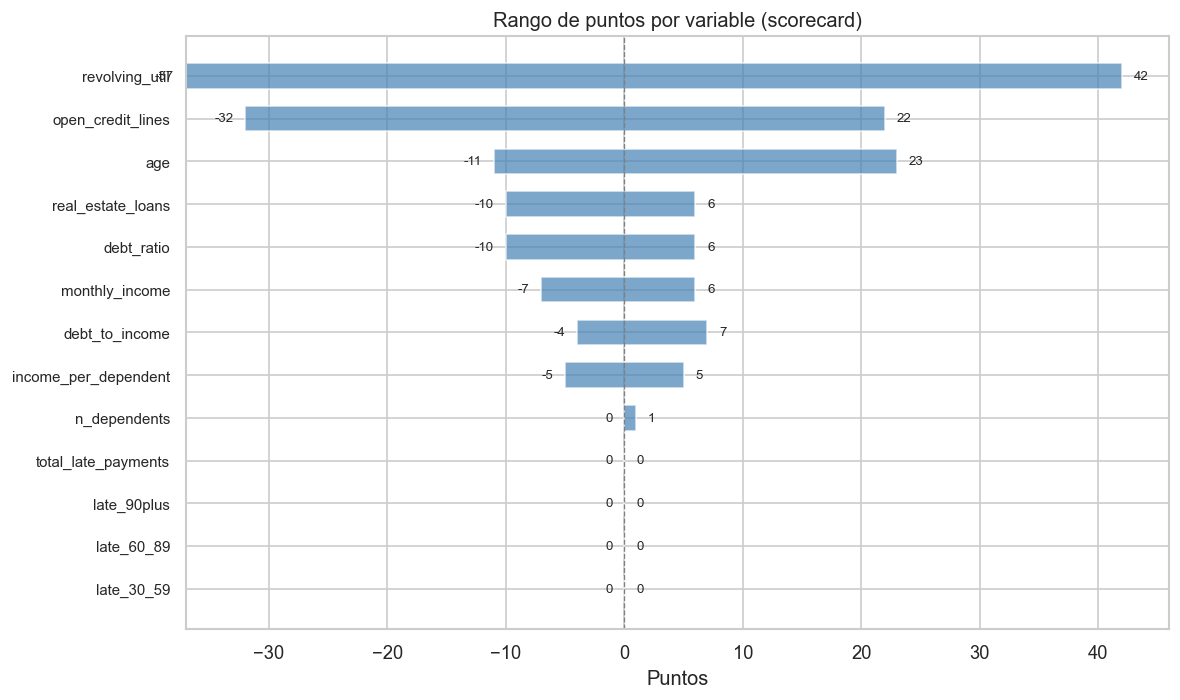

In [6]:
pt = scorecard.scorecard_table_.groupby('variable')['points_int'].agg(['min', 'max'])
pt['range'] = pt['max'] - pt['min']
pt = pt.sort_values('range', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(pt))

for i, (var, row) in enumerate(pt.iterrows()):
    ax.barh(i, row['max'] - row['min'], left=row['min'],
            color='steelblue', alpha=0.7, edgecolor='white', height=0.6)
    ax.text(row['min'] - 1, i, f"{int(row['min'])}", va='center', ha='right', fontsize=8)
    ax.text(row['max'] + 1, i, f"{int(row['max'])}", va='center', ha='left', fontsize=8)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(pt.index, fontsize=9)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Puntos')
ax.set_title('Rango de puntos por variable (scorecard)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '14_scorecard_points_range.png', bbox_inches='tight')
plt.show()

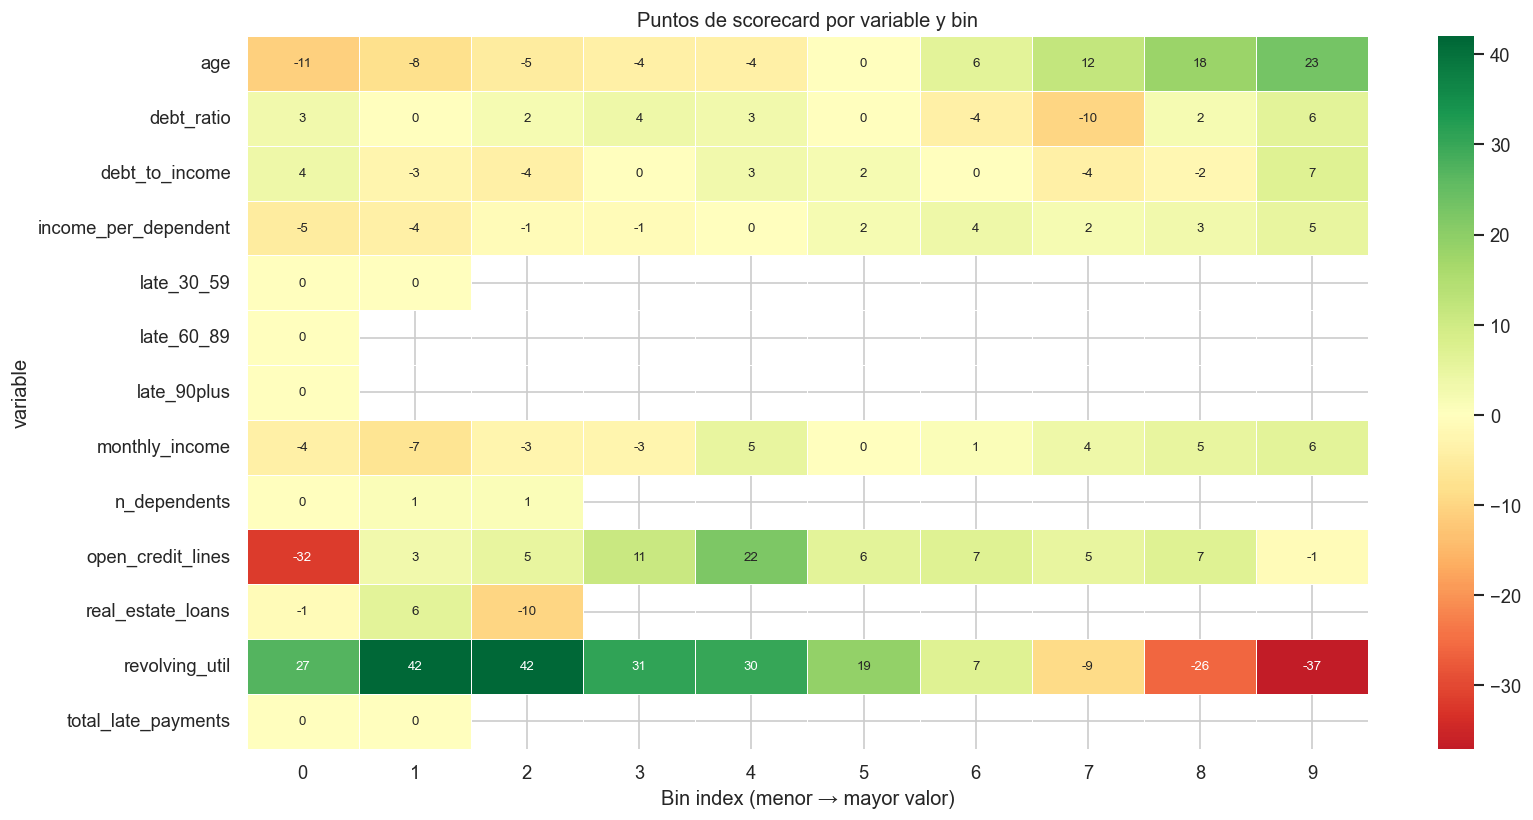

In [7]:
# Heatmap de puntos por variable × bin
pivot = scorecard.scorecard_table_.pivot_table(
    index='variable', columns='bin_index', values='points_int', aggfunc='first'
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Puntos de scorecard por variable y bin', fontsize=12)
ax.set_xlabel('Bin index (menor → mayor valor)')
plt.tight_layout()
plt.savefig(FIGURES / '15_scorecard_heatmap.png', bbox_inches='tight')
plt.show()

## 6. Distribución de scores en el set de test

Verificamos que la distribución de scores sea razonable y que las bandas de riesgo capturen la separación entre buenos y malos pagadores.

In [8]:
scores_df = scorecard.score_batch(X_test_raw)
scores_df['target'] = y_test.values

print('Distribución de scores (test):')
print(scores_df['score'].describe().round(1).to_string())

print('\nDistribución por banda de riesgo:')
band_summary = scores_df.groupby('risk_band').agg(
    n=('score', 'count'),
    default_rate=('target', 'mean'),
    score_mean=('score', 'mean'),
).round(3)
display(band_summary)

Distribución de scores (test):
count    30000.0
mean       571.4
std         40.5
min        448.0
25%        544.0
50%        577.0
75%        602.0
max        666.0

Distribución por banda de riesgo:


,n,default_rate,score_mean
risk_band,,,
High,8496,0.164,519.020
Low,57,0.018,654.947
Medium,21447,0.028,591.901


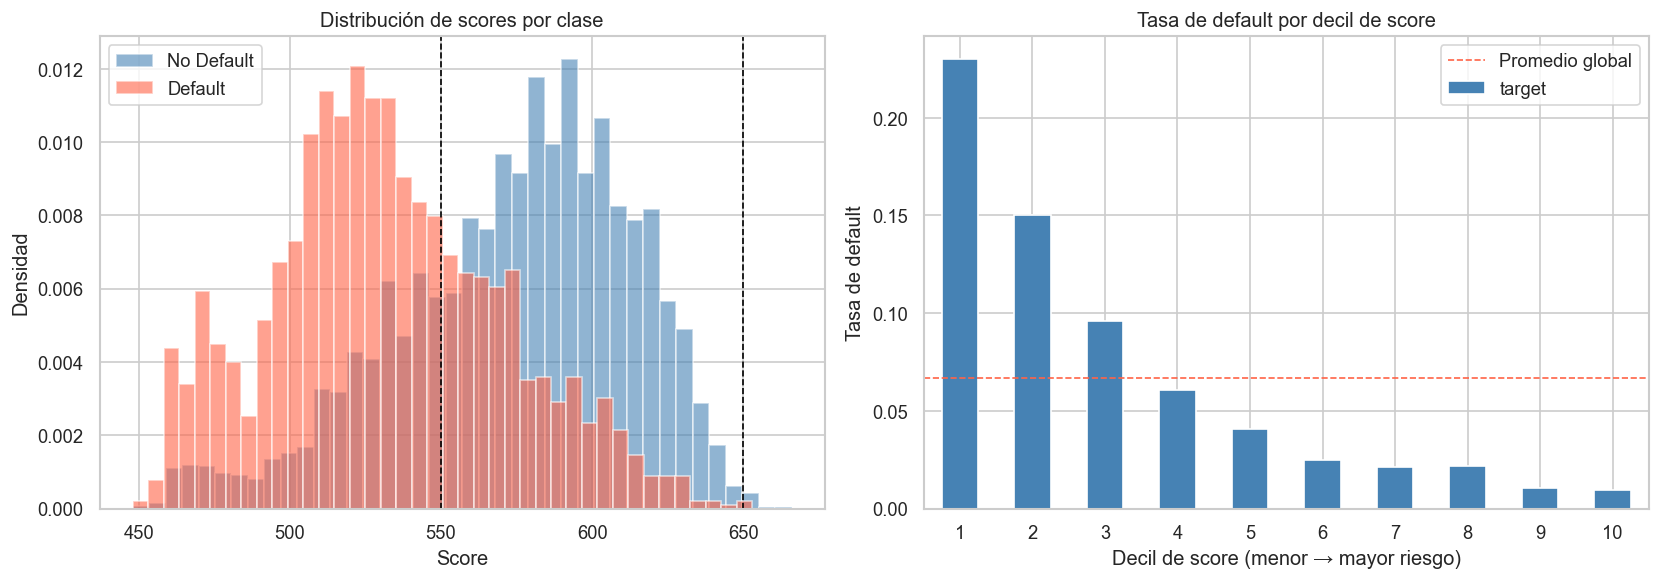

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de scores por clase
for target_val, color, label in [(0, 'steelblue', 'No Default'), (1, 'tomato', 'Default')]:
    subset = scores_df[scores_df['target'] == target_val]['score']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)

for thresh, ls in [(550, '--'), (650, '--')]:
    axes[0].axvline(thresh, color='black', linestyle=ls, linewidth=1)

axes[0].set_xlabel('Score')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de scores por clase')
axes[0].legend()

# Tasa de default por decil de score
scores_df['score_decil'] = pd.qcut(scores_df['score'], q=10, duplicates='drop')
default_by_decil = scores_df.groupby('score_decil', observed=True)['target'].mean()
default_by_decil.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_xlabel('Decil de score (menor → mayor riesgo)')
axes[1].set_ylabel('Tasa de default')
axes[1].set_title('Tasa de default por decil de score')
axes[1].set_xticklabels([str(i+1) for i in range(len(default_by_decil))], rotation=0)
axes[1].axhline(y_test.mean(), color='tomato', linestyle='--', linewidth=1, label='Promedio global')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / '16_score_distribution.png', bbox_inches='tight')
plt.show()

## 7. Función `calcular_score` — demostración con perfiles reales

In [10]:
# Perfiles de ejemplo extraídos del dataset
perfiles = {
    'cliente_bajo_riesgo': {
        'revolving_util': 0.05, 'age': 52, 'late_30_59': 0, 'debt_ratio': 0.15,
        'monthly_income': 8000, 'open_credit_lines': 8, 'late_90plus': 0,
        'real_estate_loans': 1, 'late_60_89': 0, 'n_dependents': 2,
        'debt_to_income': 1200, 'total_late_payments': 0, 'income_per_dependent': 2667,
    },
    'cliente_borderline': {
        'revolving_util': 0.55, 'age': 38, 'late_30_59': 1, 'debt_ratio': 0.45,
        'monthly_income': 4500, 'open_credit_lines': 6, 'late_90plus': 0,
        'real_estate_loans': 1, 'late_60_89': 0, 'n_dependents': 2,
        'debt_to_income': 2025, 'total_late_payments': 1, 'income_per_dependent': 1500,
    },
    'cliente_alto_riesgo': {
        'revolving_util': 0.92, 'age': 29, 'late_30_59': 3, 'debt_ratio': 0.80,
        'monthly_income': 2200, 'open_credit_lines': 4, 'late_90plus': 2,
        'real_estate_loans': 0, 'late_60_89': 1, 'n_dependents': 3,
        'debt_to_income': 1760, 'total_late_payments': 6, 'income_per_dependent': 550,
    },
}

for nombre, perfil in perfiles.items():
    resultado = scorecard.score(perfil)
    print(f'\n══ {nombre.upper()} ══')
    print(f"  Score:             {resultado['score']}")
    print(f"  Prob. default:     {resultado['probability_default']:.2%}")
    print(f"  Decisión:          {resultado['decision']}")
    print(f"  Banda de riesgo:   {resultado['risk_band']}")
    print('  Top 3 factores:')
    for f in resultado['breakdown'][:3]:
        print(f"    {f['feature']:25s} | valor={f['value']:8.2f} | puntos={f['points']:+d}")


══ CLIENTE_BAJO_RIESGO ══
  Score:             600
  Prob. default:     1.96%
  Decisión:          MANUAL_REVIEW
  Banda de riesgo:   Medium
  Top 3 factores:
    revolving_util            | valor=    0.05 | puntos=+31
    open_credit_lines         | valor=    8.00 | puntos=+6
    real_estate_loans         | valor=    1.00 | puntos=+6

══ CLIENTE_BORDERLINE ══
  Score:             548
  Prob. default:     10.81%
  Decisión:          REJECT
  Banda de riesgo:   High
  Top 3 factores:
    open_credit_lines         | valor=    6.00 | puntos=+11
    revolving_util            | valor=    0.55 | puntos=-9
    age                       | valor=   38.00 | puntos=-8

══ CLIENTE_ALTO_RIESGO ══
  Score:             503
  Prob. default:     36.58%
  Decisión:          REJECT
  Banda de riesgo:   High
  Top 3 factores:
    revolving_util            | valor=    0.92 | puntos=-26
    age                       | valor=   29.00 | puntos=-11
    debt_ratio                | valor=    0.80 | puntos=-10


## 8. Serialización del scorecard

In [11]:
scorecard.save(MODELS / 'scorecard.joblib')
joblib.dump(logreg, MODELS / 'logreg_woe.joblib')

print('Archivos guardados:')
print('  models/saved/scorecard.joblib')
print('  models/saved/scorecard_table.csv')
print('  models/saved/logreg_woe.joblib')

Archivos guardados:
  models/saved/scorecard.joblib
  models/saved/scorecard_table.csv
  models/saved/logreg_woe.joblib


## Resumen Fase 5

**Scorecard construida con:**
- Logistic Regression sobre WoE-encoded features
- Escala estándar bancaria: A=600, PDO=20, odds base=1:50
- Puntos enteros por bin, aditivos y auditables

**Bandas de decisión:** < 550 Rechazar | 550–650 Manual | > 650 Aprobar

**Outputs:**
- `models/saved/scorecard.joblib` — objeto Scorecard serializado
- `models/saved/scorecard_table.csv` — tabla exportable
- `reports/figures/14–16` — visualizaciones de la scorecard

**Próximo paso:** `06_model_explainability_shap.ipynb`